In [10]:
#Standard
from pathlib import Path
from typing import List, Tuple
import logging

#Data-handling
import pandas as pd
from PIL import Image

#rdkit imports
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import RDLogger
from rdkit.Chem import rdMolDescriptors

#drawing to console
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices = True

"""
### 'Generate_Arynes_From_Arenes.ipynb' - @GCH v1.0 - last updt. 05/10/2026

### Notebook Overview:
This notebook contains code to generate Aryne SMILES strings from Arene SMILES. A Reaction SMARTS defintion is applied 
to all valid mols extracted from an incoming Pandas DataFrame's 'smiles' column, generating all possible Aryne SMILES. 
The newly minted Aryne SMILES and Aryne_IDs (ex: aryne_12) are appended to a new Pandas DataFrame and written to a an
output .csv file: 'Arenes_and_Generated_Arynes.csv' that is written to the /Module3 directory. 

### Motivation:
A robust and transparent means of generating all possible arynes from a parent arene. Generate SMILES and prepare for DFT campaign. 

### How to Use this Notebook: 
1. Define relevant Paths to output files in the PATH cell below
2. Run all cells in the notebook
3. Some cells are "interactive" in the sense that you can render specific arenes/arynes

### Planned Features:
1. More robust and class-agnostic molecular validation post-SMARTS
"""

In [11]:
"""
Define Paths and Relevant Directories in this cell. 
"""

#path containing the current script (Module3 dir)
mod3_dir = Path.cwd() 

#the project TLD is 1 "parent" above current dir
project_tld = mod3_dir.parent

In [12]:
def validate_dataframe_format(df: pd.DataFrame, required_cols: List[str]) -> bool:
    """
    Function: Validate DataFrame has required columns and basic structure for data import

    Inputs: 
        - df: pd.DataFrame; a Pandas DataFrame to parse for required_cols
        - required_cols: List[str]; a list of column headers required for some task

    Returns:
        - Bool; True = df is OK; False = df not correct
    """

    #check that the passed info is indeed a pd.DF
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame")

    #check the passed df for column headers passed as a list
    missing_cols = [col for col in required_cols if col not in df.columns]

    #if some cols are missing, report to user
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    #if df is completely empty, report to user
    if df.empty:
        raise ValueError("DataFrame is empty")

    #return True if everything OK
    return True

In [13]:
def draw_n_mols_to_console(list_of_mols: List[Chem.Mol], number_of_mols: int, mols_per_row: int = 6, legend_labels: List[str] = None) -> Image:
    """
    Function: This method will render a 2D image of the specified molecules.

    Input:
        - list_of_mols: List[Chem.Mol
        - number_of_mols: int; integer value for the number of mols to draw total
        - mols_per_row: int = 6; integer value for # of mols per row
        - legend_labels: List[str] = None; a list of arene_ids or etc. to label drawn mols

    Returns:
        - mol_image: Image (PIL) - image to draw in console
    """

    #take a slice of the list based on number requested
    mols_slice = list_of_mols[:number_of_mols]

    #double check that all the mols are valid    
    valid_mols = [mol for mol in mols_slice if mol is not None]

    #adjust image settings as needed
    mol_image = Draw.MolsToGridImage(
        valid_mols,
        molsPerRow=mols_per_row,
        subImgSize=(200, 200),
        legends=legend_labels,
        useSVG=False
        )

    #return an image object for display
    return mol_image

In [14]:
def show_2d_specific_arene(arene_df: pd.DataFrame, target_arene_id: str) -> Image:
    """
    Function: This method will render a 2D image of a specific arene_ID

    Inputs:
        - arene_df: pd.DataFrame; a dataframe of col. format "arene_ID", "arene_smiles"
        - target_arene_id: str; a string specifying an ID, ex: "arene_10" 

    Returns:
        arene_img: Image; A PIL image of the referenced arene
    """

    print(f"Displaying: {target_arene_id}")
    
    #makes a 1-row DF from our original DF corresponding to the arene_ID number we pass
    target_row = arene_df[arene_df['arene_ID'] == target_arene_id]

    #capture the target arene SMILES
    arene_smile = target_row['arene_smiles'].iloc[0]

    #format some printed output
    print(f"2D Arene SMILES: {arene_smile}")  

    #Attempt to convert the SMILES string to RDKit Mol Object 
    try:
        #here we attempt the conversion and explicitly require sanitization
        arene_mol = Chem.MolFromSmiles(arene_smile, sanitize = True)

        #If the mol is convertible (not NONE type) => Proceed with code 
        if arene_mol is not None:

            #Plot the parent SMILES as a sanity check
            arene_list = [arene_mol]
            arene_img = draw_n_mols_to_console(arene_list, len(arene_list), 6, legend_labels=[target_arene_id])

            #return the image
            return arene_img
            
    #some SMILES may be unconvertible to RDKIT Mols/catch some weird errors
    except Exception as e:
        print("Error on Mol")

In [15]:
def show_2d_range_of_arenes(arene_df: pd.DataFrame, target_arene_ids: List[str]) -> Image:
    """
    Function: This method will render a 2D image of the specified arene_ids

    Inputs:
        - arene_df: pd.DataFrame; a dataframe of col. format "arene_ID", "arene_smiles"
        - target_arene_ids: List[str]; a list of strings specifying IDs, ex: ["arene_10", "arene_20", "arene_30"] 

    Returns:
        - arene_img: Image; a 2D grid image (PIL) returned for display to console
    """

    # Create a list to store the RDKit Mol objects
    mols = []
    legend_labels = []

    print(f"Displaying user-specified range of arenes...\n")

    #for each of the passed arene_IDs, grab the SMILES and confirm the arene_ID
    for target_arene_id in target_arene_ids:
        
        # makes a 1-row DF from our original DF corresponding to the arene_ID number we pass
        target_row = arene_df[arene_df['arene_ID'] == target_arene_id]

        # capture the target arene SMILES
        arene_smile = target_row['arene_smiles'].iloc[0]

        # #Debug
        # print(f"\t{target_arene_id}: {arene_smile}")  

        try:
            # Attempt to convert the SMILES string to RDKit Mol Object 
            arene_mol = Chem.MolFromSmiles(arene_smile, sanitize=True)

            # If the mol is convertible (not NONE type) => Proceed with code 
            if arene_mol is not None:
                #append the working mol and its label to relevant lists
                mols.append(arene_mol)
                legend_labels.append(target_arene_id)

        #error handling
        except Exception as e:
            print(f"Error processing {target_arene_id}: {e}")

    #If valid mols were obtained, draw them
    if mols:
        # Plot the parent SMILES as a sanity check
        arene_img = draw_n_mols_to_console(mols, len(mols), 6, legend_labels=legend_labels)

        #return the image
        return arene_img
        
    else:
        print("No valid molecules found.")

In [16]:
def smiles_to_mols_rdkit(list_of_smiles: List[str], sanitization=True) -> List[Chem.Mol]:
    """
    Function: Converts an SD-file containing a single molecule to an RDKit mol object. Returns the mol object. 
    
    Input:
        - list_of_smiles: List[str]; a list of raw SMILES strings to convert to Mol objects
        - sanitization = True (default val True) - use RDKIT sanitization on the SMILES str; good/safe practice
        
    Returns:
        - list_of_valid_mols: List[Chem.Mol]; a list of validated RDKit Mol objects
    """

    #init a list to store validated RDKit mol objects
    list_of_valid_mols = []
    #Init a counter to keep track of any failed SMILES => Mol conversions
    failed_count = 0

    #loop over each of the raw SMILES strings in the incoming list    
    #Using 'enumerate' gives us access to the index of each SMILES in the list
    for index, smile in enumerate(list_of_smiles):
        
        try: #Attempt to convert the SMILES string to RDKit Mol Object 
            #here we attempt the conversion and explicitly require sanitization
            mol = Chem.MolFromSmiles(smile, sanitize = sanitization)

            if mol is not None: #If the mol is convertible (not NONE type), 
                #append the mol to our list of validated mols
                list_of_valid_mols.append(mol)

            else: #if the SMILE cant be converted, 
                failed_count += 1 #iterate our failed counter
                continue
                
        #some SMILES may be unconvertible to RDKIT Mols/catch some weird errors
        except Exception as e:
            failed_count += 1 #keep track of how many mols failed
            continue

    #if any mols failed, print how many 
    if failed_count >= 1:
        print(f"\nFailed to convert {failed_count} SMILES to RDKit Mols.")

    #give some feedback on the # of successfully converted Mols
    print(f"\nSucessfully converted {len(list_of_valid_mols)} SMILES to valid RDKit Mols.")    
    
    #return the list of validated RDkit mols
    return list_of_valid_mols

In [17]:
def deduplicate_list_of_mols(list_of_mols: List[Chem.Mol], printing: bool = True) -> List[Chem.Mol]:
    """
    Function: Given a list of RDKit mol objects, 

    Input:
        - list_of_mols: List[Chem.Mol]; a list of validated RDKit mol objects
        - printing: bool = True; controls printing to console

    Returns:
        - unique_mols: List[Chem.Mol]; a list of deduplicated and validated RDKit mol objects
            (based on canonical smiles) 
    """

    if printing:
        print(f"\nChecking for any duplicate SMILES following skeletal editing...")
    
    #convert the list of mols into canonical SMILES with RDKit 
    canonical_smiles = [Chem.MolToSmiles(mol) for mol in list_of_mols]
    #print(f"num canonical_smiles = {len(canonical_smiles)}")

    #Loop over the SMILES and add them to a list if they aren't currently in the list
    unique_smiles = []
    [unique_smiles.append(smile) for smile in canonical_smiles if smile not in unique_smiles]

    #print(f"num unique_smiles = {len(unique_smiles)}")
    
    #convert the unique SMILES back into RDKit mols
    unique_mols = [Chem.MolFromSmiles(smi) for smi in unique_smiles]

    num_duplicates = len(canonical_smiles) - len(unique_mols)

    if printing:
        if num_duplicates:
            print(f"\tRemoved {num_duplicates} duplicate SMILES")
            
        elif num_duplicates == 0:
            print(f"\tNo duplicate SMILES following skeletal editing.")

    #return the unique mols
    return(unique_mols)

In [18]:
def convert_specific_arene(arene_df: pd.DataFrame, target_arene_id: str) -> Image:
    """
    Function: This method serves as a demo/useful tool to show all the possible arynes given a specific arene ID #

    Inputs:
        - arene_df: pd.DataFrame; a dataframe of col. format "arene_ID", "arene_smiles"
        - target_arene_id: str; a string specifying an ID, ex: "arene_10" 

    Returns:
        An image of possible aryne product(s) following deduplication    
    """

    #Define a Reaction SMARTS expression to apply
    smarts_arene_to_aryne = AllChem.ReactionFromSmarts('[cH1D2;R:1]:[cH1D2;R:2]>>[c:1]#[c:2]')

    #makes a 1-row DF from our original DF corresponding to the arene_ID number we pass
    target_row = arene_df[arene_df['arene_ID'] == target_arene_id]

    #capture the target arene SMILES
    arene_smile = target_row['arene_smiles'].iloc[0]

    print(f"Attempting to convert {target_arene_id} to possible arynes...\n\tArene SMILES: {arene_smile}")  

    try: #Attempt to convert the SMILES string to RDKit Mol Object 
        #here we attempt the conversion and explicitly require sanitization
        arene_mol = Chem.MolFromSmiles(arene_smile, sanitize = True)

        #If the mol is convertible (not NONE type) => Proceed with code 
        if arene_mol is not None:

            #Plot the parent SMILES as a sanity check
            arene_list = [arene_mol]
            arene_img = draw_n_mols_to_console(arene_list, 1, 6, legend_labels=[target_arene_id])
            display(arene_img)

            print(f"\nApplying RXN SMARTS to '{target_arene_id}'...") 
            
            #apply reaction SMARTS to our mol
            #RunReactants returns a tuple of tuples, ex: ((product1, product2, ...), (product1, product 2, ...) ...) 
            #Each inner tuple represents one possible reaction outcome
            #Each element in inner tuple is one product molecule
            reaction_results = smarts_arene_to_aryne.RunReactants((arene_mol, ))

            #list comprehension to unpack our tuple of tuples; unpack to list of mols
            aryne_products = [mol for result_tuple in reaction_results for mol in result_tuple]
            
            #deduplicate mols via canonical SMILES dedup.
            unique_products = deduplicate_list_of_mols(aryne_products)

            #Need to check here if the mols in unique_products are valid with a try/except
            validated_products = []
            invalid_count = 0

            #loop over each product
            for product in unique_products:
                try:
                    # Attempt to sanitize the molecule
                    Chem.SanitizeMol(product)
                    
                    # Additional validation: check if we can generate a valid SMILES
                    test_smiles = Chem.MolToSmiles(product)
                    
                    # Try to convert back to mol to ensure roundtrip validity
                    test_mol = Chem.MolFromSmiles(test_smiles)
                    
                    if test_mol is not None:
                        validated_products.append(product)
                    else:
                        invalid_count += 1
                        
                except (Chem.AtomValenceException, Chem.KekulizeException, ValueError) as e:
                    invalid_count += 1
                    continue
                except Exception as e:
                    invalid_count += 1
                    continue
            
            # Update unique_products with validated molecules
            unique_products = validated_products
            
            if invalid_count > 0:
                print(f"Note: {invalid_count} invalid molecule(s) were filtered out during validation.")
            
            # Check if we have any valid products left
            if len(unique_products) == 0:
                print(f"\nNo valid arynes could be generated from '{target_arene_id}'.")
                return None            
            
            print(f"\nRXN SMARTS '{target_arene_id}' generated {len(unique_products)} unique aryne(s):")

            #print the SMILES generated
            for product in unique_products:
                aryne_smile = Chem.MolToSmiles(product)
                print(f"\tGenerated Aryne SMILES: {aryne_smile}")

            #generate an image of the created aryne(s)
            arynes_img = draw_n_mols_to_console(unique_products, 6)

            #return the image
            return(arynes_img)
            
    #some SMILES may be unconvertible to RDKIT Mols/catch some weird errors
    except Exception as e:
        print("Error on Mol")

In [19]:
def validate_molecule(mol, molecule_type="general", printing=False):
    """
    Comprehensive molecule validation with optional aryne-specific checks
    
    Args:
        mol: RDKit molecule object
        molecule_type: str, "general" or "aryne" for specific validation
        printing: bool, whether to print detailed validation info
    
    Returns:
        tuple: (is_valid: bool, message: str, details: dict)
    """

    #check that the mol works
    if mol is None:
        return False, "Molecule is None", {}
    
    validation_details = {
        "atom_count": mol.GetNumAtoms(),
        "bond_count": mol.GetNumBonds(),
        "ring_count": len(Chem.GetSymmSSSR(mol)),
        "has_triple_bond": False,
        "valence_issues": []
    }
    
    try:
        # Sanitize
        Chem.SanitizeMol(mol)
        
        # Check for valid SMILES generation
        smiles = Chem.MolToSmiles(mol)
        if not smiles:
            return False, "Cannot generate SMILES", validation_details
        
        validation_details["smiles"] = smiles
        
        # Roundtrip test
        test_mol = Chem.MolFromSmiles(smiles)
        if test_mol is None:
            return False, "Failed roundtrip validation", validation_details
        
        # Check for unusual valences or structures
        for atom in mol.GetAtoms():
            total_valence = atom.GetTotalValence()
            if total_valence > 6:  # Reasonable upper limit
                validation_details["valence_issues"].append(
                    f"Atom {atom.GetSymbol()} (idx {atom.GetIdx()}) has valence {total_valence}"
                )
        
        # Aryne-specific validation
        if molecule_type == "aryne":
            # Check for triple bonds (arynes should have C≡C)
            for bond in mol.GetBonds():
                if bond.GetBondType() == Chem.BondType.TRIPLE:
                    validation_details["has_triple_bond"] = True
                    break
            
            # Arynes should have at least one triple bond
            if not validation_details["has_triple_bond"]:
                return False, "No triple bond found (not a valid aryne)", validation_details
            
            # Check for reasonable size (arynes are typically small-medium molecules)
            if validation_details["atom_count"] > 50:  # Adjust threshold as needed
                return False, f"Molecule too large for typical aryne ({validation_details['atom_count']} atoms)", validation_details
        
        # If we have valence issues, it's invalid
        if validation_details["valence_issues"]:
            return False, f"Valence issues: {'; '.join(validation_details['valence_issues'])}", validation_details
        
        if printing:
            print(f"   ✅ Validation passed: {smiles}")
            if molecule_type == "aryne":
                print(f"      Triple bond detected: {validation_details['has_triple_bond']}")
        
        return True, "Valid", validation_details
        
    except (Chem.AtomValenceException, Chem.KekulizeException, ValueError) as e:
        return False, f"Validation error: {str(e)}", validation_details
    except Exception as e:
        return False, f"Unexpected error: {str(e)}", validation_details

In [20]:
def convert_arenes_to_arynes(id_and_smiles_df: pd.DataFrame, printing: bool = False) -> List:
    """
    Function: Applies a defined Reaction SMARTS to each Arene SMILES contained in the passed dataframe. 
        Assumes that your data columns are formatted as "arene_ID", "arene_smiles". Returns a new list
        of format [[arene_ID, arene_smiles, aryne_smiles]] that will populate a new DF. 

    Inputs:
        - id_and_smiles_df: pd.DataFrame; a Pandas dataframe of format described above
        - printing: bool = False; controls printing to console, pass True to print

    Returns: 
        - arene_and_generated_arynes: List; a list of lists: [[arene_ID, arene_smiles, aryne_smiles]] 
    """

    # Input validation
    if not isinstance(id_and_smiles_df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame")

    #We need these cols in the dataframe, explicitly
    required_cols = ['arene_ID', 'arene_smiles']
    missing_cols = [col for col in required_cols if col not in id_and_smiles_df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    #if the dataframe is empty, error out/return empty list
    if id_and_smiles_df.empty:
        print("Warning: Empty DataFrame provided")
        return []

    #give user some default output
    print(f"Applying Arene => Aryne Rxn SMARTS to target DataFrame...")
    print(f"\tFound {len(id_and_smiles_df)} Arene SMILES...\n")

    #Define a Reaction SMARTS expression to apply
    smarts_arene_to_aryne = AllChem.ReactionFromSmarts('[cH1D2;R:1]:[cH1D2;R:2]>>[c:1]#[c:2]')

    #turn off the logger to quiet output
    RDLogger.DisableLog('rdApp.*')

    #init a list to store generated arynes:
    #Format is list of lists: [[arene_ID, arene_smiles, aryne_smiles], ...] 
    arene_and_generated_arynes = []
    
    #Now apply Rxn SMARTS across the whole dataset of arenes to generate all possible arynes
    for index, row in id_and_smiles_df.iterrows():
        
        #capture the arene_ID from ID col
        target_arene_id = row['arene_ID']
    
        #capture the arene parent SMILES string
        arene_smile = row['arene_smiles']
    
        #debug printing
        if printing:
            print(f"Attempting to convert {target_arene_id} to possible arynes...\n\tArene SMILES: {arene_smile}")
    
        #Attempt to convert the SMILES string to RDKit Mol Object
        try: 
            
            #attempt the SMILES => Mol conversion and explicitly require sanitization
            arene_mol = Chem.MolFromSmiles(arene_smile, sanitize = True)
    
            #If the mol is convertible (not NONE type) => Proceed with code 
            if arene_mol is not None:
    
                #debug printing
                if printing:
                    print(f"\nApplying RXN SMARTS to '{target_arene_id}'...")
                    
                #apply reaction SMARTS to our mol
                #RunReactants returns a tuple of tuples, ex: ((product1, product2, ...), (product1, product 2, ...) ...) 
                #Each inner tuple represents one possible reaction outcome
                #Each element in inner tuple is one product molecule
                reaction_results = smarts_arene_to_aryne.RunReactants((arene_mol, ))
    
                #list comprehension to unpack our tuple of tuples; unpack to list of mols
                aryne_products = [mol for result_tuple in reaction_results for mol in result_tuple]
                
                #deduplicate mols via canonical SMILES dedup.
                if printing:
                    unique_products = deduplicate_list_of_mols(aryne_products, printing=True)
                else:
                    unique_products = deduplicate_list_of_mols(aryne_products, printing=False)
    
                #Need to check here if the mols in unique_products are valid with a try/except
                validated_products = []
                invalid_count = 0
    
                #loop over each product
                for product in unique_products:
                        
                    try:
                        # Attempt to sanitize the molecule
                        Chem.SanitizeMol(product)
                        
                        # Additional validation: check if we can generate a valid SMILES
                        test_smiles = Chem.MolToSmiles(product)
                        
                        # Try to convert back to mol to ensure roundtrip validity
                        test_mol = Chem.MolFromSmiles(test_smiles)
                        
                        if test_mol is not None:
                            validated_products.append(product)
                        else:
                            invalid_count += 1

                    #error handling
                    except (Chem.AtomValenceException, Chem.KekulizeException, ValueError) as e:
                        invalid_count += 1
                        continue

                    #error handling
                    except Exception as e:
                        invalid_count += 1
                        continue
    
                # Update unique_products with validated molecules
                unique_products = validated_products

                if printing:
                    if invalid_count > 0:
                        print(f"Note: {invalid_count} invalid molecule(s) were filtered out during validation.")
                    
                    # Check if we have any valid products left
                    if len(unique_products) == 0:
                        print(f"\nNo valid arynes could be generated from '{target_arene_id}'.")        

                    #print summary of how many possible; can check with the cell above
                    print(f"\nRXN SMARTS '{target_arene_id}' generated {len(unique_products)} unique aryne(s).\n")
    
                #Convert product mols to SMILES and append to our list of lists
                for product in unique_products:

                    # Validate the generated aryne molecule
                    is_valid, message, details = validate_molecule(product, molecule_type="aryne", printing=printing)
                    if is_valid:
                        # Convert the valid product molecule back to SMILES string
                        aryne_smile = Chem.MolToSmiles(product)
        
                        # Debug printing
                        if printing:
                            print(f"\tGenerated aryne SMILES: {aryne_smile}")
        
                        # Append the current arene ID, arene SMILES, and generated aryne SMILES to the output list
                        arene_and_generated_arynes.append([target_arene_id, arene_smile, aryne_smile])

                    #some sort of error happened
                    else:
                        if printing:
                            print(f"Validation failed for generated aryne of {target_arene_id}: {message}")


                    # #add explicit H's
                    # product_with_h = Chem.AddHs(product)
                    
                    # #convert mol to SMILES str
                    # aryne_smile = Chem.MolToSmiles(product_with_h)
    
                    # #append the aryne to paired list of arene_id/arene_SMILES/aryne_SMILES
                    # arene_and_generated_arynes.append([target_arene_id, arene_smile, aryne_smile])
                          
        #some SMILES may be unconvertible to RDKIT Mols/catch some weird errors
        except Exception as e:
            continue

    #give user some default output
    print(f"Successfully generated {len(arene_and_generated_arynes)} Aryne SMILES from {len(id_and_smiles_df)} Arene SMILES.")

    #return our list of lists
    #format: [[arene_ID, arene_smiles, aryne_smiles], ...] 
    return arene_and_generated_arynes

In [6]:
"""
Import Data from .csv "Confirmed_Arene_Cores.csv" in Module2 directory.
Checks the imported DF for data/expected column headers. 
"""

#The Module2 directory contains the .csv we need in this notebook
input_csv_dir = project_tld / "Module2_Prepare_Arene_Cores" / "Confirmed_Arene_Cores.csv"

#Read in the specified .csv as a pd DataFrame
incoming_data = pd.read_csv(input_csv_dir)

#list containing the required cols
required_cols = ["arene_ID", "arene_smiles"]

#check that the passed DF is valid for our purposes (has correct cols and data)
validated_df = validate_dataframe_format(incoming_data, required_cols)

#if the DF is ok, proceed and give some info
if validated_df:
    print(f"Found {len(incoming_data)} SMILES strings in target csv file: '{input_csv_dir.name}'\n")

#otherwise, fix the df
else:
    print(f"Passed DataFrame could not be parsed for SMILES or does not contain correct col. headers.\n")

#print some of the df
incoming_data.head()

Found 8581 SMILES strings in target csv file: 'Confirmed_Arene_Cores.csv'



,arene_ID,arene_smiles
0,arene_1,O=c1nc2ccc(=O)sc2co1
1,arene_2,O=c1cc2ccsc(=O)n2nn1
2,arene_3,O=c1cc2ncccc2no1
3,arene_4,O=c1ccn2c(=O)oc(=O)nc2[nH]1
4,arene_5,O=c1cc2occc(=O)n2c(=O)s1



Sucessfully converted 6 SMILES to valid RDKit Mols.


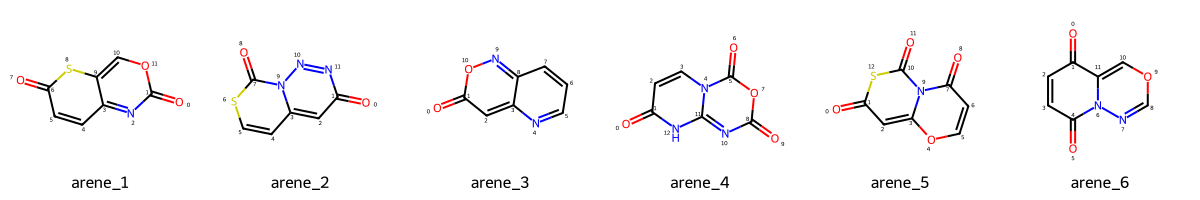

In [12]:
"""
This cell renders the first "N" user-specified SMILES as 2D ima(default=6) from the incoming dataset to the console as 2D images.
Change the integer value assigned to "number_mols_to_draw" to draw more. 
"""

#change this to print more mols
number_mols_to_draw = 6

#Grab all SMILES in the incoming dataframe and convert them to RDKit mol objects
incoming_arene_smiles = incoming_data['arene_smiles'].tolist()

#also grab the arene_ID column for labeling
incoming_arene_ids = incoming_data['arene_ID'].to_list()

#slice our lists by the number_mols_to_draw val
arene_smiles_to_draw = incoming_arene_smiles[:number_mols_to_draw]
arene_id_labels = incoming_arene_ids[:number_mols_to_draw]

#convert list of SMILES to RDKit mols
arene_mols = smiles_to_mols_rdkit(arene_smiles_to_draw)

#visual check of the first n mols, pass the arene_IDs as legend labels
sampled_arenes = draw_n_mols_to_console(arene_mols, number_mols_to_draw, legend_labels=arene_id_labels)
display(sampled_arenes)

Displaying: arene_1000
2D Arene SMILES: O=c1cc[nH]n2nnc(=O)n12


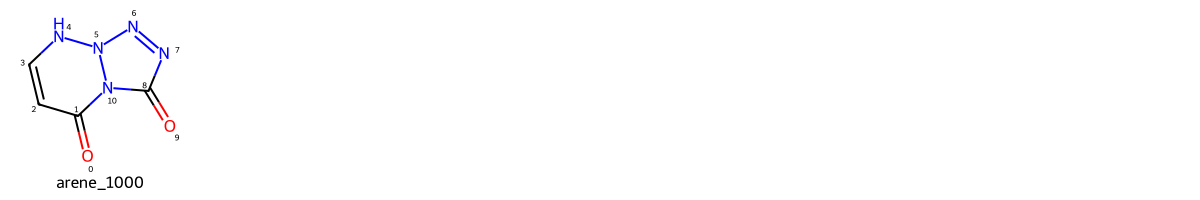

In [13]:
"""
This cell will render a specific arene_id in 2D.
Change the value of "arene_id", below. 
"""

#specify an arene to render by arene_ID
target_arene = show_2d_specific_arene(incoming_data, "arene_1000")
display(target_arene)

Displaying user-specified range of arenes...



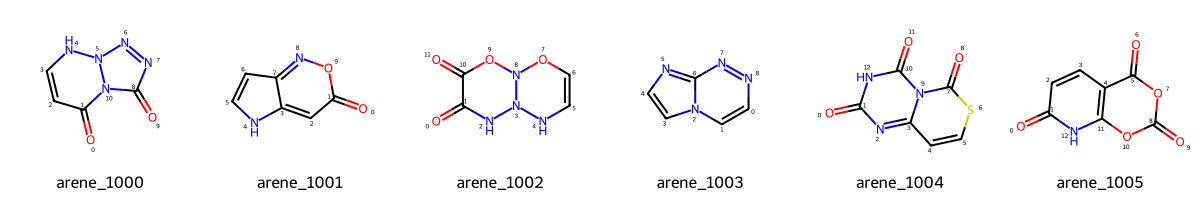

In [14]:
"""
This cell will render a specific range of arenes from a dataframe in 2D.
Specify a range of mols to draw by changing the value of "range_of_ids", below
"""

#specify a range of ID numbers to draw in 2D
range_of_ids = range(1000, 1006)

#create a list of arene_ids based on range
arene_ids_to_draw = []
for i in range_of_ids:
    arene_ids_to_draw.append(f"arene_{i}")
    
#pass our list of arene_IDs to render
range_of_arenes = show_2d_range_of_arenes(incoming_data, arene_ids_to_draw)
display(range_of_arenes)

Attempting to convert arene_1885 to possible arynes...
	Arene SMILES: O=c1[nH]cnn2occon12


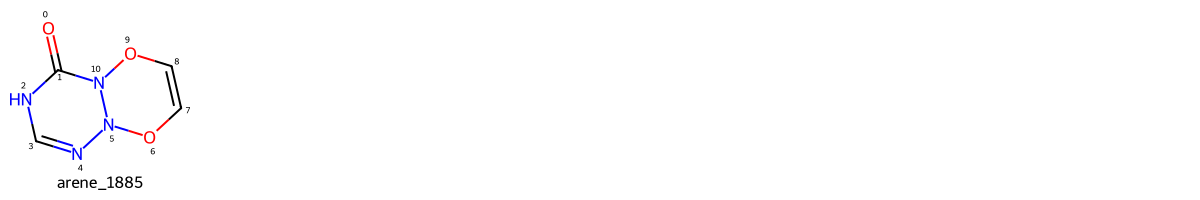


Applying RXN SMARTS to 'arene_1885'...

Checking for any duplicate SMILES following skeletal editing...
	Removed 1 duplicate SMILES

RXN SMARTS 'arene_1885' generated 1 unique aryne(s):
	Generated Aryne SMILES: O=c1[nH]cnn2oc#con12


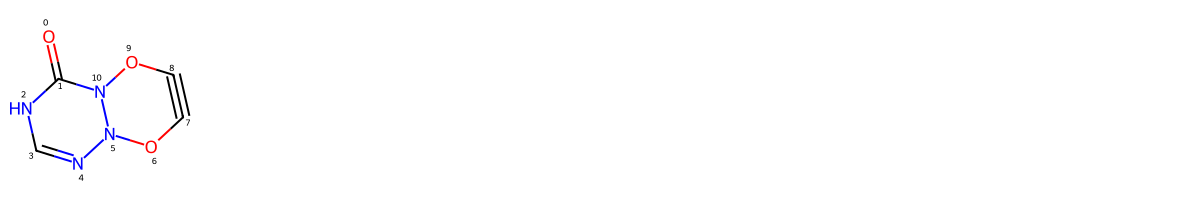

In [15]:
"""
This cell converts a user-specified arene (by arene_ID) to all possible derivable arynes. 
Change the value of "arene_id", below, to generate possible arynes for other arenes.
"""

#specify different arene_IDs to generate possible products following deduplication
generated_aryne = convert_specific_arene(incoming_data, "arene_1885")
display(generated_aryne)

In [16]:
"""
This cell will apply Reaction SMARTS to all arenes in the dataset to generate all possible unique arynes. 
The result of this cell is a new pd.DataFrame with format: [arene_ID', arene_smiles, aryne_ID, aryne_smiles]
"""

#apply Arene => Aryne + H2 conversion to all arene SMILES
#a list of lists is returned
arenes_and_arynes_list = convert_arenes_to_arynes(incoming_data, printing=True)

#make a dataframe from the generated data
paired_arene_aryne_df = pd.DataFrame(arenes_and_arynes_list, columns=['arene_ID', 'arene_smiles', 'aryne_smiles'])

#add IDs for the generated arynes:
aryne_ids = []
i = 1
for i in range(1,len(paired_arene_aryne_df)+1):
    aryne_ids.append(f'aryne_{i}')
    i += 1

#add aryne_IDs to the DF
paired_arene_aryne_df['aryne_ID'] = aryne_ids

#reorder the cols and prep to write to .csv
output_df = paired_arene_aryne_df[['arene_ID', 'arene_smiles', 'aryne_ID', 'aryne_smiles']]
output_df.head()

Applying Arene => Aryne Rxn SMARTS to target DataFrame...
	Found 8581 Arene SMILES...

Attempting to convert arene_1 to possible arynes...
	Arene SMILES: O=c1nc2ccc(=O)sc2co1

Applying RXN SMARTS to 'arene_1'...

Checking for any duplicate SMILES following skeletal editing...
	Removed 1 duplicate SMILES

RXN SMARTS 'arene_1' generated 1 unique aryne(s).

   ✅ Validation passed: O=c1nc2c#cc(=O)sc2co1
      Triple bond detected: True
	Generated aryne SMILES: O=c1nc2c#cc(=O)sc2co1
Attempting to convert arene_2 to possible arynes...
	Arene SMILES: O=c1cc2ccsc(=O)n2nn1

Applying RXN SMARTS to 'arene_2'...

Checking for any duplicate SMILES following skeletal editing...
	Removed 1 duplicate SMILES

RXN SMARTS 'arene_2' generated 1 unique aryne(s).

   ✅ Validation passed: O=c1cc2c#csc(=O)n2nn1
      Triple bond detected: True
	Generated aryne SMILES: O=c1cc2c#csc(=O)n2nn1
Attempting to convert arene_3 to possible arynes...
	Arene SMILES: O=c1cc2ncccc2no1

Applying RXN SMARTS to 'arene_3'...


,arene_ID,arene_smiles,aryne_ID,aryne_smiles
0,arene_1,O=c1nc2ccc(=O)sc2co1,aryne_1,O=c1nc2c#cc(=O)sc2co1
1,arene_2,O=c1cc2ccsc(=O)n2nn1,aryne_2,O=c1cc2c#csc(=O)n2nn1
2,arene_3,O=c1cc2ncccc2no1,aryne_3,O=c1cc2ncc#cc2no1
3,arene_4,O=c1ccn2c(=O)oc(=O)nc2[nH]1,aryne_4,O=c1c#cn2c(=O)oc(=O)nc2[nH]1
4,arene_5,O=c1cc2occc(=O)n2c(=O)s1,aryne_5,O=c1cc2oc#cc(=O)n2c(=O)s1


In [17]:
"""
This cell will output a 'Arenes_and_Generated_Arynes.csv' file to the specified directory path. 
The format of the output .csv is: Arene_ID, Arene_SMILES, Aryne_ID, Aryne_SMILES. 
This output file is used by the next module in the workflow to write DFT input files.
"""

#Make a name/path for the output file
csv_name = mod3_dir / "Arenes_and_Generated_Arynes.csv"

#output the file to the targeted directory
output_df.to_csv(csv_name)

#print a summary to user
print(f"\033[1m'{csv_name.name}' containing {len(output_df)} aryne SMILES written '/{mod3_dir.name}/'.\033[0m")

'Arenes_and_Generated_Arynes.csv' containing 9459 aryne SMILES written '/Module3_Generate_Arynes_From_Arenes/'.
